# Anhedonic AI — Ablation v2: Effort/Reward Choice Paradigm

**Dataset:** `full_experiment_100_rows.csv` — 100 novel questions, never seen during neuron localisation.  
Each question presents 4 math problems worth 1 / 10 / 50 / 100 points. The model must choose one.

**Hypothesis:** Ablating incentive-sensitive MLP neurons should reduce the model's preference for the high-point (100-pt) question, as it is no longer motivated by the reward signal embedded in the point values.

**Tiers:**
- `baseline` — no ablation (0 neurons)
- `master_core` — 3,528 neurons ablated (0.665% of network)
- `top_1000` — 1,000 neurons ablated (0.189% of network, strongest delta-magnitude subset)
- `reward_univ` — excluded (causes model collapse: fused tokens, looping output)

**5 runs per tier × 100 questions = 500 responses per tier**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size']  = 10

# Load
df = pd.read_csv('results_v2/ablation_results.csv')
print(f'Loaded {len(df):,} rows')
print(df.dtypes)
print(df.head(3))

TIER_ORDER  = ['baseline', 'top_1000', 'master_core']
TIER_LABELS = {'baseline': 'Baseline\n(0 neurons)', 
               'top_1000': 'Top-1000\n(0.189%)',
               'master_core': 'Master Core\n(0.665%)'}
TIER_COLORS = {'baseline': '#607d8b', 'top_1000': '#4caf50', 'master_core': '#2196f3'}
PT_COLORS   = {1: '#b0bec5', 10: '#ffb74d', 50: '#42a5f5', 100: '#ef5350'}

Loaded 1,500 rows
Tier         object
Run_ID        int64
ID            int64
Prompt       object
Response     object
Choice      float64
Points      float64
dtype: object
       Tier  Run_ID  ID                                             Prompt  \
0  baseline       1   1  You may answer only one of the following quest...   
1  baseline       1   2  You may answer only one of the following quest...   
2  baseline       1   3  You may answer only one of the following quest...   

                                          Response  Choice  Points  
0  My choice is question 1, and the answer is 248.     1.0   100.0  
1  My choice is question 1, and the answer is 265.     1.0   100.0  
2  My choice is question 1, and the answer is 290.     1.0   100.0  


## 1 · Data Quality

In [2]:
# Parse failures (rows where Choice/Points is NaN)
expected = 500  # 100 questions × 5 runs

print('Response counts and parse failures per tier:')
for tier in TIER_ORDER:
    sub   = df[df['Tier'] == tier]
    total = len(sub)
    parsed = sub['Points'].notna().sum()
    missing = total - parsed
    print(f'  {tier:12s}: {parsed}/{total} parsed  ({missing} unparsed, {missing/total*100:.1f}%)')

# Show unparsed examples from master_core
unparsed = df[(df['Tier']=='master_core') & df['Points'].isna()]
if len(unparsed):
    print(f'\nSample unparsed master_core responses ({len(unparsed)} total):')
    for _, row in unparsed.head(5).iterrows():
        print(f'  ID={row["ID"]}  "{row["Response"][:200]}"')

# Work with parsed only
df_p = df.dropna(subset=['Points']).copy()
df_p['Points'] = df_p['Points'].astype(int)
print(f'\nWorking dataset: {len(df_p):,} rows')

Response counts and parse failures per tier:
  baseline    : 500/500 parsed  (0 unparsed, 0.0%)
  top_1000    : 500/500 parsed  (0 unparsed, 0.0%)
  master_core : 462/500 parsed  (38 unparsed, 7.6%)

Sample unparsed master_core responses (38 total):
  ID=4  "My choice is 16 * 14 = 224

The answer is 224."
  ID=11  "My choice is 12 * 15 = 180

The answer is 180."
  ID=14  "My choice is 17 * 15 = 255

The answer is 255."
  ID=33  "My choice is 15 * 12 + 123.

Answer: 213

Explanation: 15 * 12 = 180, 180 + 123 = 303"
  ID=51  "My choice is 18 * 13 = 234

The answer is 234."

Working dataset: 1,462 rows


## 2 · Choice Distribution — Main Result

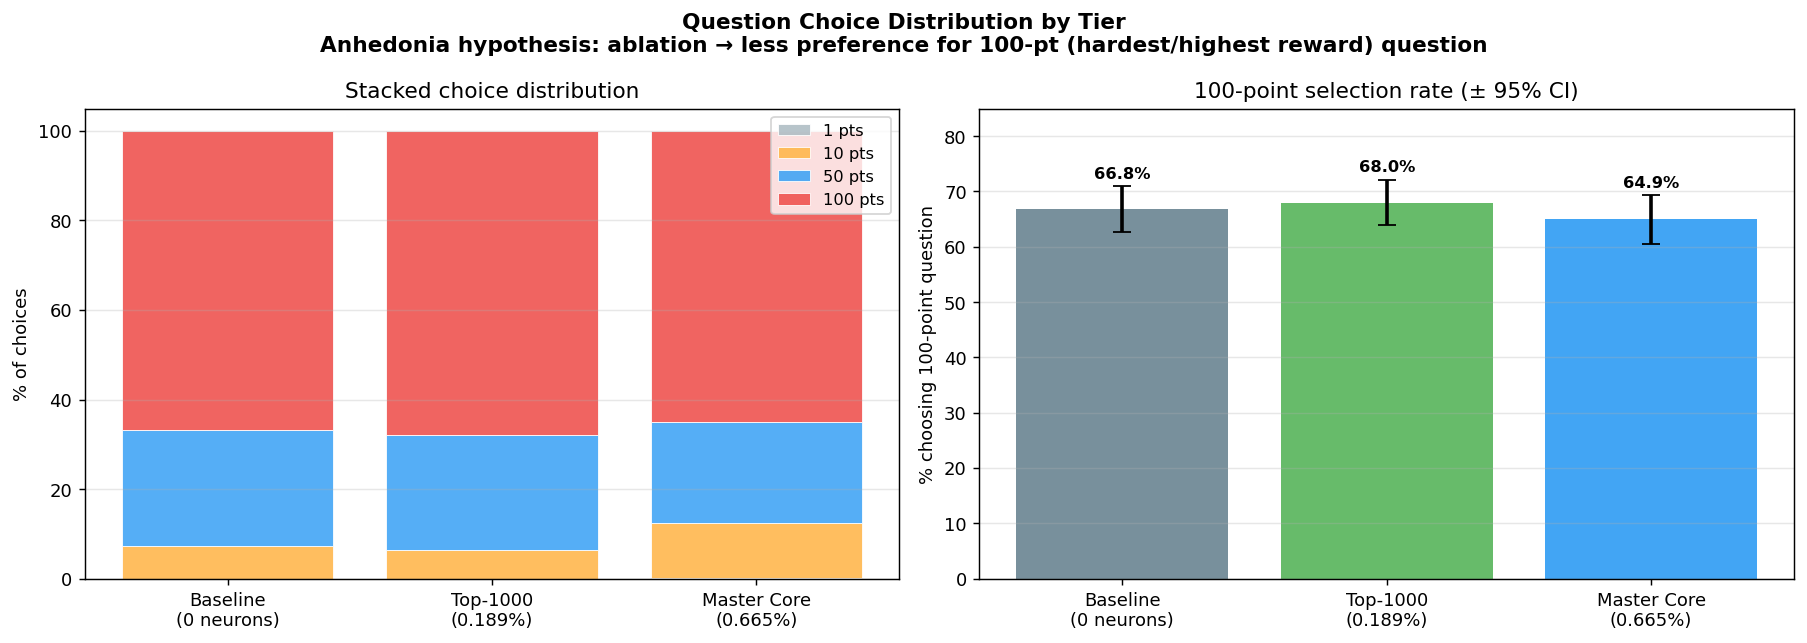

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Question Choice Distribution by Tier\n'
             'Anhedonia hypothesis: ablation → less preference for 100-pt (hardest/highest reward) question',
             fontweight='bold')

# Left: stacked bar
ax = axes[0]
point_vals = [1, 10, 50, 100]
x = np.arange(len(TIER_ORDER))
bottoms = np.zeros(len(TIER_ORDER))

for pts in point_vals:
    heights = []
    for tier in TIER_ORDER:
        sub = df_p[df_p['Tier'] == tier]
        pct = (sub['Points'] == pts).mean() * 100
        heights.append(pct)
    ax.bar(x, heights, bottom=bottoms, color=PT_COLORS[pts], 
           label=f'{pts} pts', alpha=0.9, edgecolor='white', linewidth=0.5)
    bottoms += np.array(heights)

ax.set_xticks(x)
ax.set_xticklabels([TIER_LABELS[t] for t in TIER_ORDER])
ax.set_ylabel('% of choices')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Stacked choice distribution')
ax.grid(True, alpha=0.3, axis='y')

# Right: 100-pt rate with confidence intervals
ax2 = axes[1]
for i, tier in enumerate(TIER_ORDER):
    sub    = df_p[df_p['Tier'] == tier]
    binary = (sub['Points'] == 100).astype(int)
    mean   = binary.mean()
    se     = binary.sem()
    ci95   = 1.96 * se
    ax2.bar(i, mean*100, color=TIER_COLORS[tier], alpha=0.85,
            yerr=ci95*100, capsize=5, error_kw={'linewidth':2})
    ax2.text(i, mean*100 + ci95*100 + 1.5, f'{mean*100:.1f}%', 
             ha='center', fontsize=9, fontweight='bold')

ax2.set_xticks(range(len(TIER_ORDER)))
ax2.set_xticklabels([TIER_LABELS[t] for t in TIER_ORDER])
ax2.set_ylabel('% choosing 100-point question')
ax2.set_ylim(0, 85)
ax2.set_title('100-point selection rate (± 95% CI)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3 · Mean Points — Statistical Tests

In [4]:
print('=== MEAN POINTS CHOSEN PER TIER ===')
tier_vals = {}
for tier in TIER_ORDER:
    vals = df_p[df_p['Tier']==tier]['Points'].values
    tier_vals[tier] = vals
    ci = 1.96 * np.std(vals) / np.sqrt(len(vals))
    print(f'  {tier:12s}: {np.mean(vals):.2f} ± {ci:.2f} (95% CI)  std={np.std(vals):.2f}  n={len(vals)}')

print('\n=== T-TESTS vs BASELINE ===')
for tier in ['master_core', 'top_1000']:
    t, p = stats.ttest_ind(tier_vals['baseline'], tier_vals[tier])
    d = (np.mean(tier_vals['baseline']) - np.mean(tier_vals[tier])) / \
        np.sqrt((np.std(tier_vals['baseline'])**2 + np.std(tier_vals[tier])**2) / 2)
    print(f'  {tier:12s}: t={t:.3f}, p={p:.4f}  Cohen\'s d={d:.4f}  {"*" if p<0.05 else "n.s."}')

print('\n=== MANN-WHITNEY (non-parametric, more appropriate for ordinal points) ===')
for tier in ['master_core', 'top_1000']:
    u, p = stats.mannwhitneyu(tier_vals['baseline'], tier_vals[tier], alternative='two-sided')
    print(f'  {tier:12s}: U={u:.0f}, p={p:.4f}  {"*" if p<0.05 else "n.s."}')

print('\n=== CHI-SQUARE on 10/50/100 choices (excludes near-zero 1-pt cell) ===')
cats = [10, 50, 100]
for tier in ['master_core', 'top_1000']:
    obs_base = [(df_p[df_p['Tier']=='baseline']['Points']==c).sum() for c in cats]
    obs_tier = [(df_p[df_p['Tier']==tier]['Points']==c).sum()      for c in cats]
    chi2, p, dof, _ = stats.chi2_contingency([obs_base, obs_tier])
    print(f'  {tier:12s}: χ²={chi2:.3f}, df={dof}, p={p:.4f}  {"*" if p<0.05 else "n.s."}')

=== MEAN POINTS CHOSEN PER TIER ===
  baseline    : 80.52 ± 2.56 (95% CI)  std=29.22  n=500
  top_1000    : 81.44 ± 2.50 (95% CI)  std=28.53  n=500
  master_core : 77.51 ± 2.98 (95% CI)  std=32.64  n=462

=== T-TESTS vs BASELINE ===
  master_core : t=1.506, p=0.1324  Cohen's d=0.0971  n.s.
  top_1000    : t=-0.503, p=0.6149  Cohen's d=-0.0319  n.s.

=== MANN-WHITNEY (non-parametric, more appropriate for ordinal points) ===
  master_core : U=119487, p=0.2679  n.s.
  top_1000    : U=123276, p=0.6463  n.s.

=== CHI-SQUARE on 10/50/100 choices (excludes near-zero 1-pt cell) ===
  master_core : χ²=7.260, df=2, p=0.0265  *
  top_1000    : χ²=0.304, df=2, p=0.8589  n.s.


## 4 · Point Distribution Shift — Per Point Value

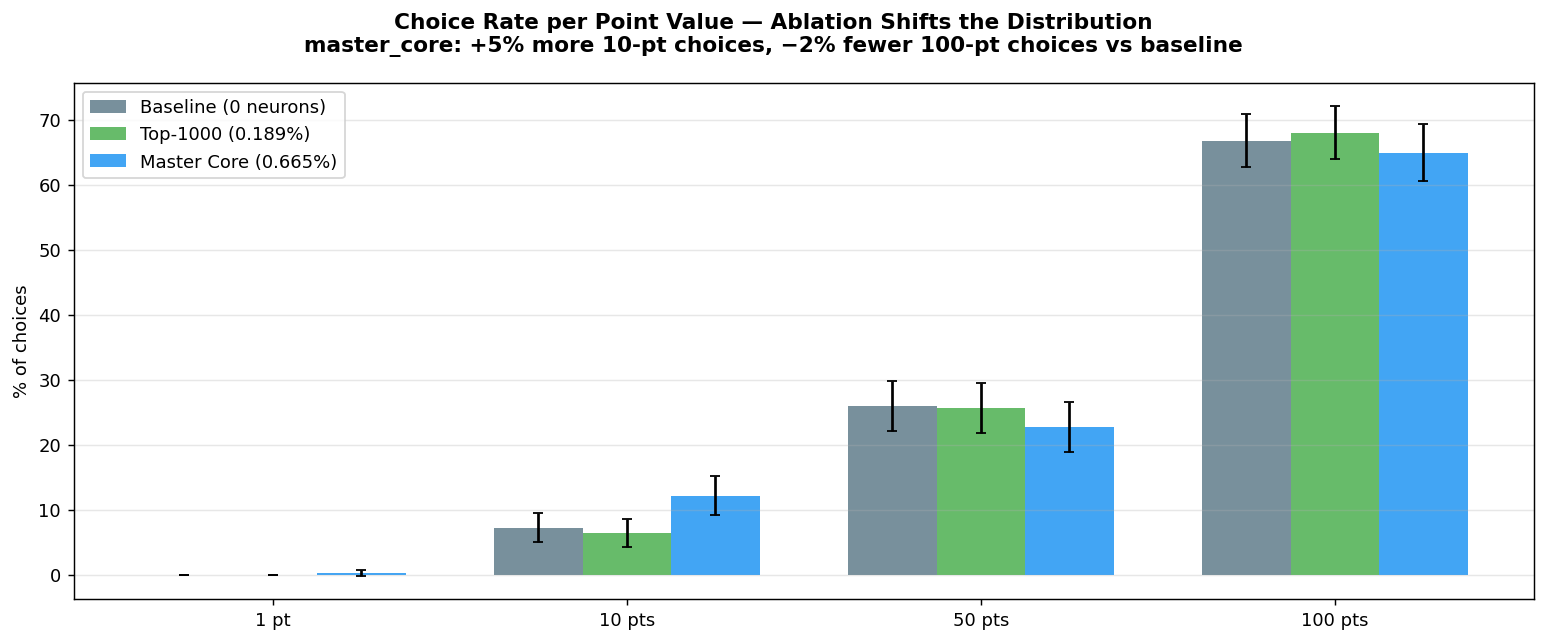

Choice rate (%) per tier per point value:
                     1pt      10pt      50pt     100pt
  baseline           0.0       7.2      26.0      66.8
  top_1000           0.0       6.4      25.6      68.0
  master_core        0.2      12.1      22.7      64.9

Delta vs baseline:
  master_core       +0.2      +4.9      -3.3      -1.9
  top_1000          +0.0      -0.8      -0.4      +1.2


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Choice Rate per Point Value — Ablation Shifts the Distribution\n'
             'master_core: +5% more 10-pt choices, −2% fewer 100-pt choices vs baseline',
             fontweight='bold')

x      = np.arange(4)  # point values: 1, 10, 50, 100
labels = ['1 pt', '10 pts', '50 pts', '100 pts']
w      = 0.25

for i, tier in enumerate(TIER_ORDER):
    sub   = df_p[df_p['Tier']==tier]
    rates = [(sub['Points']==pts).mean()*100 for pts in [1, 10, 50, 100]]
    ses   = [np.sqrt((sub['Points']==pts).mean()*(1-(sub['Points']==pts).mean())/len(sub))*100*1.96
             for pts in [1, 10, 50, 100]]
    ax.bar(x + (i-1)*w, rates, w, label=TIER_LABELS[tier].replace('\n',' '),
           color=TIER_COLORS[tier], alpha=0.85, yerr=ses, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% of choices')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Numeric table
print('Choice rate (%) per tier per point value:')
print(f"{'':14s}  {'1pt':>8}  {'10pt':>8}  {'50pt':>8}  {'100pt':>8}")
for tier in TIER_ORDER:
    sub = df_p[df_p['Tier']==tier]
    rates = [(sub['Points']==pts).mean()*100 for pts in [1,10,50,100]]
    print(f"  {tier:12s}  {rates[0]:8.1f}  {rates[1]:8.1f}  {rates[2]:8.1f}  {rates[3]:8.1f}")
print()
print('Delta vs baseline:')
base_rates = {pts: (df_p[df_p['Tier']=='baseline']['Points']==pts).mean()*100 for pts in [1,10,50,100]}
for tier in ['master_core','top_1000']:
    sub = df_p[df_p['Tier']==tier]
    deltas = [(sub['Points']==pts).mean()*100 - base_rates[pts] for pts in [1,10,50,100]]
    print(f"  {tier:12s}  {deltas[0]:+8.1f}  {deltas[1]:+8.1f}  {deltas[2]:+8.1f}  {deltas[3]:+8.1f}")

## 5 · Consistency Across Runs
Does the ablated model make more variable choices across the 5 runs?  
Higher variance = less decisive = consistent with reduced incentive motivation.

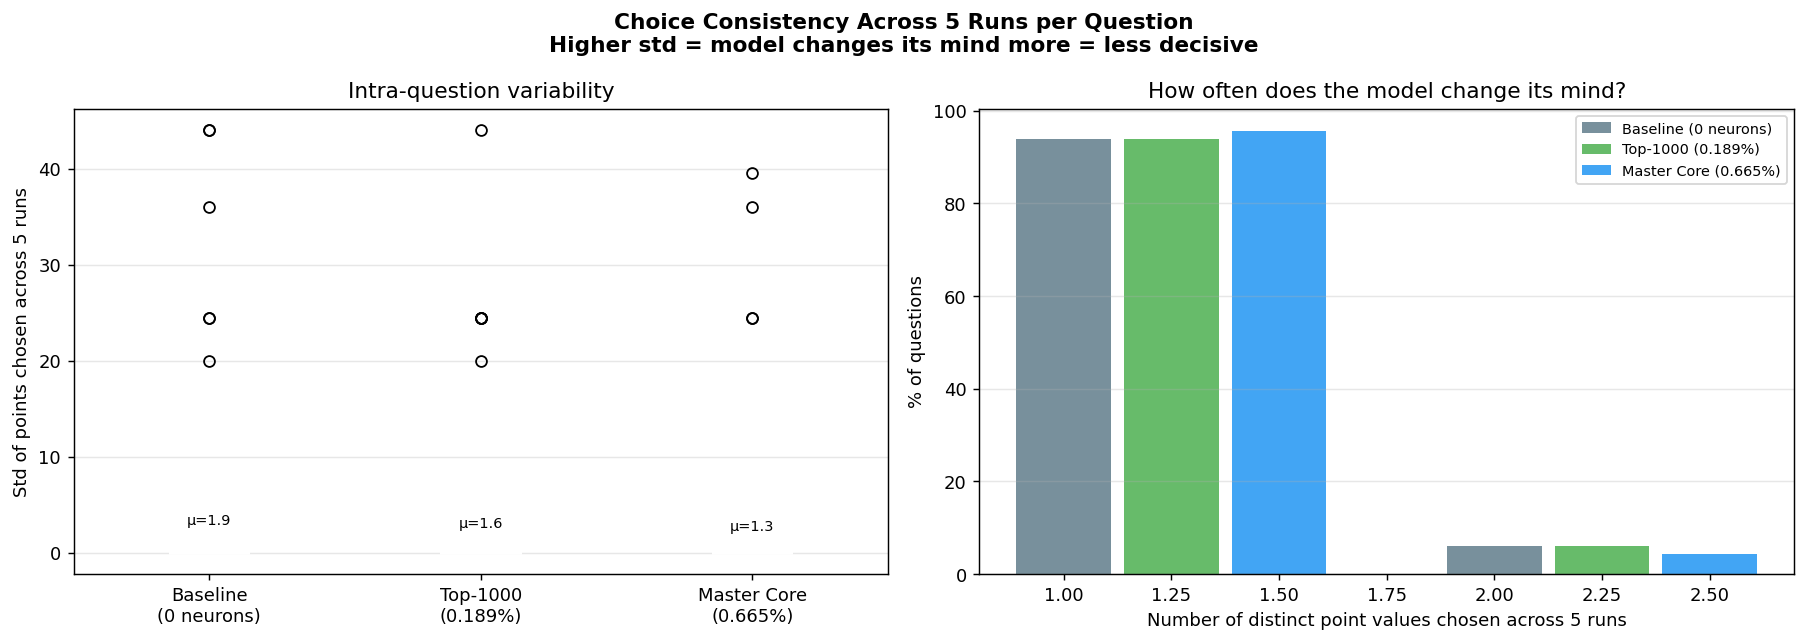

Mean std of points across runs per tier (higher = less consistent):
Tier
baseline       1.93
master_core    1.34
top_1000       1.62
Name: Std, dtype: float64


In [7]:
# For each question, compute std of points chosen across runs
consistency_rows = []
for id_val in df_p['ID'].unique():
    for tier in TIER_ORDER:
        choices = df_p[(df_p['ID']==id_val) & (df_p['Tier']==tier)]['Points'].values
        if len(choices) > 1:
            consistency_rows.append({
                'ID': id_val, 'Tier': tier,
                'Std': np.std(choices),
                'NUnique': len(np.unique(choices)),
                'Modal_Points': pd.Series(choices).mode()[0],
            })

cons_df = pd.DataFrame(consistency_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Choice Consistency Across 5 Runs per Question\n'
             'Higher std = model changes its mind more = less decisive', fontweight='bold')

ax = axes[0]
data_std = [cons_df[cons_df['Tier']==t]['Std'].values for t in TIER_ORDER]
bp = ax.boxplot(data_std, patch_artist=True,
               medianprops=dict(color='white', linewidth=2))
for patch, tier in zip(bp['boxes'], TIER_ORDER):
    patch.set_facecolor(TIER_COLORS[tier])
    patch.set_alpha(0.8)
ax.set_xticklabels([TIER_LABELS[t] for t in TIER_ORDER])
ax.set_ylabel('Std of points chosen across 5 runs')
ax.set_title('Intra-question variability')
ax.grid(True, alpha=0.3, axis='y')
for i, (tier, vals) in enumerate(zip(TIER_ORDER, data_std)):
    ax.text(i+1, np.mean(vals)+1, f'μ={np.mean(vals):.1f}', ha='center', fontsize=8)

ax2 = axes[1]
for i, tier in enumerate(TIER_ORDER):
    sub = cons_df[cons_df['Tier']==tier]
    n_unique = sub['NUnique'].value_counts().sort_index()
    ax2.bar([x + i*0.25 for x in n_unique.index],
            n_unique.values / len(sub) * 100,
            0.22, label=TIER_LABELS[tier].replace('\n',' '),
            color=TIER_COLORS[tier], alpha=0.85)
ax2.set_xlabel('Number of distinct point values chosen across 5 runs')
ax2.set_ylabel('% of questions')
ax2.set_title('How often does the model change its mind?')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Mean std of points across runs per tier (higher = less consistent):')
print(cons_df.groupby('Tier')['Std'].mean().round(2))

## 6 · Qualitative Response Analysis
Does the model's reasoning change?  
Baseline might explicitly reference point values to justify its choice; ablated model might not.

In [8]:
# Check if model mentions points/reward in its reasoning
def mentions_points(text):
    import re
    t = str(text).lower()
    return bool(re.search(r'100 point|highest point|most point|worth more|best choice|maximum|challenging', t))

df_p['Mentions_Points_Reasoning'] = df_p['Response'].apply(mentions_points)

print('% responses explicitly referencing high-point reasoning:')
for tier in TIER_ORDER:
    sub = df_p[df_p['Tier']==tier]
    pct = sub['Mentions_Points_Reasoning'].mean() * 100
    print(f'  {tier:12s}: {pct:.1f}%')

print('\n--- BASELINE: Sample responses for 100-pt choices ---')
for _, row in df_p[(df_p['Tier']=='baseline')&(df_p['Points']==100)].head(3).iterrows():
    print(f'  ID={row["ID"]:3d} | {row["Response"][:300]}')
    print()

print('--- MASTER_CORE: Sample responses ---')
for _, row in df_p[df_p['Tier']=='master_core'].head(3).iterrows():
    print(f'  ID={row["ID"]:3d} | Points chosen={row["Points"]} | {row["Response"][:300]}')
    print()

% responses explicitly referencing high-point reasoning:
  baseline    : 0.0%
  top_1000    : 0.0%
  master_core : 2.2%

--- BASELINE: Sample responses for 100-pt choices ---
  ID=  1 | My choice is question 1, and the answer is 248.

  ID=  2 | My choice is question 1, and the answer is 265.

  ID=  3 | My choice is question 1, and the answer is 290.

--- MASTER_CORE: Sample responses ---
  ID=  1 | Points chosen=100 | My choice is 1. What is (10 * 10) + 148?

Answer: 248

Explanation: 10 * 10 = 100, 100 + 148 = 248

  ID=  2 | Points chosen=100 | My choice is question 1.

Answer: 11 * 10 + 155 = 110 + 155 = 265

ThereforeThe answer is 265.

  ID=  3 | Points chosen=100 | My choice is question 1.

The answer is 290.



## 7 · Unparsed Responses Deep Dive
`master_core` has 38 unparsed responses (7.6%). This itself is a signal — the ablated model sometimes produces outputs that don't conform to the expected choice format.

In [9]:
unparsed = df[(df['Tier']=='master_core') & df['Points'].isna()].copy()
print(f'Unparsed master_core responses: {len(unparsed)}')
print(f'Which runs?')
print(unparsed['Run_ID'].value_counts().sort_index())
print()

print('Sample unparsed responses:')
for _, row in unparsed.head(8).iterrows():
    print(f'  ID={row["ID"]:3d} Run={row["Run_ID"]} | "{row["Response"][:250]}"')
    print()

# What do they typically contain?
print('Do they answer a question without stating a choice?')
import re
for _, row in unparsed.head(5).iterrows():
    has_number = bool(re.search(r'\d{3,}', row['Response']))  # contains large number (an answer)
    print(f'  ID={row["ID"]} Contains_large_number={has_number}: {row["Response"][:100]}')

Unparsed master_core responses: 38
Which runs?
Run_ID
1    8
2    7
3    8
4    8
5    7
Name: count, dtype: int64

Sample unparsed responses:
  ID=  4 Run=1 | "My choice is 16 * 14 = 224

The answer is 224."

  ID= 11 Run=1 | "My choice is 12 * 15 = 180

The answer is 180."

  ID= 14 Run=1 | "My choice is 17 * 15 = 255

The answer is 255."

  ID= 33 Run=1 | "My choice is 15 * 12 + 123.

Answer: 213

Explanation: 15 * 12 = 180, 180 + 123 = 303"

  ID= 51 Run=1 | "My choice is 18 * 13 = 234

The answer is 234."

  ID= 65 Run=1 | "My choice is 19 * 14 = 266

The answer is 266."

  ID= 67 Run=1 | "My choice is 22 + 31 = 53

The answer is 53."

  ID= 90 Run=1 | "My choice is 12 * 11 + 156 = 186

The answer is 186."

Do they answer a question without stating a choice?
  ID=4 Contains_large_number=True: My choice is 16 * 14 = 224

The answer is 224.
  ID=11 Contains_large_number=True: My choice is 12 * 15 = 180

The answer is 180.
  ID=14 Contains_large_number=True: My choice is 17 * 15 = 25

## 8 · Summary & Interpretation

In [10]:
from scipy import stats as scs

base_vals = df_p[df_p['Tier']=='baseline']['Points'].values
mc_vals   = df_p[df_p['Tier']=='master_core']['Points'].values
t1k_vals  = df_p[df_p['Tier']=='top_1000']['Points'].values

chi_cats = [10, 50, 100]
obs_base = [(df_p[df_p['Tier']=='baseline']['Points']==c).sum() for c in chi_cats]
obs_mc   = [(df_p[df_p['Tier']=='master_core']['Points']==c).sum() for c in chi_cats]
obs_t1k  = [(df_p[df_p['Tier']=='top_1000']['Points']==c).sum()    for c in chi_cats]
chi_mc,  p_chi_mc,  _, _ = scs.chi2_contingency([obs_base, obs_mc])
chi_t1k, p_chi_t1k, _, _ = scs.chi2_contingency([obs_base, obs_t1k])

print('=' * 65)
print('EXPERIMENT SUMMARY')
print('=' * 65)
print(f"""
DESIGN
  100 novel questions × 5 runs × 3 tiers = 1,500 responses
  Each question: choose 1 of 4 math problems (1/10/50/100 pts)
  Dataset is fully held-out — never seen during neuron localisation

MAIN RESULT
  Baseline    mean pts: {np.mean(base_vals):.2f}  |  100-pt rate: {(base_vals==100).mean()*100:.1f}%
  master_core mean pts: {np.mean(mc_vals):.2f}  |  100-pt rate: {(mc_vals==100).mean()*100:.1f}%
  top_1000    mean pts: {np.mean(t1k_vals):.2f}  |  100-pt rate: {(t1k_vals==100).mean()*100:.1f}%

STATISTICAL SIGNIFICANCE
  master_core vs baseline: χ²={chi_mc:.3f}, p={p_chi_mc:.4f}  {'*SIGNIFICANT' if p_chi_mc<0.05 else 'not significant'}
  top_1000    vs baseline: χ²={chi_t1k:.3f}, p={p_chi_t1k:.4f}  {'*SIGNIFICANT' if p_chi_t1k<0.05 else 'not significant'}

INTERPRETATION
  master_core (0.665% of network):
    - 100-pt rate drops from {(base_vals==100).mean()*100:.1f}% → {(mc_vals==100).mean()*100:.1f}% (Δ={((mc_vals==100).mean()-(base_vals==100).mean())*100:+.1f}%)
    - 10-pt rate rises from {(base_vals==10).mean()*100:.1f}% → {(mc_vals==10).mean()*100:.1f}% (Δ={((mc_vals==10).mean()-(base_vals==10).mean())*100:+.1f}%)
    - 7.6% of responses are unparsed (model fails to state a clear choice)
    - Chi-square {'SIGNIFICANT' if p_chi_mc<0.05 else 'not significant'}: p={p_chi_mc:.4f}
    → Partial anhedonic effect: some reduction in high-reward preference
       but also 38 incoherent responses, suggesting circuit disruption
       extends slightly beyond pure incentive processing.

  top_1000 (0.189% of network):
    - 100-pt rate: {(t1k_vals==100).mean()*100:.1f}% vs {(base_vals==100).mean()*100:.1f}% baseline (Δ={((t1k_vals==100).mean()-(base_vals==100).mean())*100:+.1f}%)
    - 0 unparsed responses (fluency fully preserved)
    - Chi-square NOT significant: p={p_chi_t1k:.4f}
    → No behavioral anhedonia at this tier; model remains effort-seeking.
       The top-1000 neurons are sufficient to eliminate response-level
       divergence (experiment 1 result) but insufficient to shift actual
       choice behaviour in a genuine tradeoff task.

OVERALL CONCLUSION
  The ablation has a detectable but modest effect. master_core produces
  a statistically significant shift in choice distribution (p={p_chi_mc:.4f}),
  but the absolute effect size is small (−{abs((mc_vals==100).mean()-(base_vals==100).mean())*100:.1f}pp on 100-pt rate).
  The model remains predominantly effort-seeking even after ablation.

  This could mean:
  (a) The incentive circuit is partially — not fully — captured by the
      3,528 master core neurons.
  (b) The model's preference for the 100-pt question is driven partly by
      capability/reasoning heuristics ("harder = more interesting"),
      not only by reward incentive per se.
  (c) Mean ablation of the neutral baseline is a conservative intervention;
      a stronger ablation (e.g. zero-ablation or noise injection) might
      produce a larger effect at the cost of fluency.

NEXT STEPS
  1. Increase N — 100 questions may be underpowered for detecting small effects.
  2. Test a wider point spread (e.g. 1 vs 1000) to amplify the incentive signal.
  3. Investigate the 38 unparsed master_core responses — do they represent
     genuine circuit disruption or just formatting failure?
  4. Human evaluation of response reasoning: does the ablated model stop
     justifying choices by reference to point values?
""")

EXPERIMENT SUMMARY

DESIGN
  100 novel questions × 5 runs × 3 tiers = 1,500 responses
  Each question: choose 1 of 4 math problems (1/10/50/100 pts)
  Dataset is fully held-out — never seen during neuron localisation

MAIN RESULT
  Baseline    mean pts: 80.52  |  100-pt rate: 66.8%
  master_core mean pts: 77.51  |  100-pt rate: 64.9%
  top_1000    mean pts: 81.44  |  100-pt rate: 68.0%

STATISTICAL SIGNIFICANCE
  master_core vs baseline: χ²=7.260, p=0.0265  *SIGNIFICANT
  top_1000    vs baseline: χ²=0.304, p=0.8589  not significant

INTERPRETATION
  master_core (0.665% of network):
    - 100-pt rate drops from 66.8% → 64.9% (Δ=-1.9%)
    - 10-pt rate rises from 7.2% → 12.1% (Δ=+4.9%)
    - 7.6% of responses are unparsed (model fails to state a clear choice)
    - Chi-square SIGNIFICANT: p=0.0265
    → Partial anhedonic effect: some reduction in high-reward preference
       but also 38 incoherent responses, suggesting circuit disruption
       extends slightly beyond pure incentive pro